# Flight Delay Prediction - MLOps Project


## 1. Project Overview

This project builds a machine learning model to predict whether a scheduled flight will be delayed.

The project is designed as an end-to-end MLOps workflow, including data exploration, data processing, model training, deployment preparation, API serving, monitoring, tracing, CI/CD, containerization, Kubernetes deployment, and cloud deployment.

## 2. Problem Definition

The goal is to solve a binary classification problem:

- **Class 0:** Flight is not delayed
- **Class 1:** Flight is delayed

The prediction is made using information available from the scheduled flight, such as airline, flight number, departure time, flight length, origin airport, destination airport, and day of week.

## 3. Dataset Description

The dataset is the Airlines dataset inspired by the Data Expo flight delay dataset.

It contains 539,383 records and 8 attributes:

- Flight
- Time
- Length
- Airline
- AirportFrom
- AirportTo
- DayOfWeek
- class

The target variable is `class`.

## 4. Exploratory Data Analysis

In [34]:
from scipy.io import arff
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load ARFF dataset
data, meta = arff.loadarff("../data/raw/airlines.arff")

# Convert to DataFrame
df = pd.DataFrame(data)

# Decode categorical columns from bytes to strings if necessary
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].str.decode("utf-8")

df.head()

,Flight,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,class
0,2774.0,1235.0,80.0,MQ,DFW,CRP,5,0.0
1,2313.0,1296.0,141.0,DL,ATL,HOU,1,0.0
2,6948.0,360.0,146.0,OO,COS,ORD,4,0.0
3,1247.0,1170.0,143.0,B6,BOS,CLT,3,0.0
4,31.0,1410.0,344.0,US,OGG,PHX,6,0.0


### 4.1 Dataset Overview

In [35]:
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nDataFrame info:")
df.info()

Shape: (539383, 8)

Data types:
Flight         float64
Time           float64
Length         float64
Airline            str
AirportFrom        str
AirportTo          str
DayOfWeek          str
class          float64
dtype: object

DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 539383 entries, 0 to 539382
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Flight       539383 non-null  float64
 1   Time         539383 non-null  float64
 2   Length       539383 non-null  float64
 3   Airline      539383 non-null  str    
 4   AirportFrom  539383 non-null  str    
 5   AirportTo    539383 non-null  str    
 6   DayOfWeek    539383 non-null  str    
 7   class        539383 non-null  float64
dtypes: float64(4), str(4)
memory usage: 32.9 MB


### 4.2 Missing Values and Duplicate Analysis

This section examines missing values and duplicated records in the dataset.

Duplicate rows are not removed immediately because the dataset does not contain a specific flight date. Multiple real flights may therefore share the same scheduled characteristics. In addition, identical feature combinations may have different delay outcomes.

In [36]:
print("===== MISSING VALUES =====")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nTotal missing values:", df.isnull().sum().sum())

print("\n===== EXACT DUPLICATES =====")
exact_duplicates = df.duplicated().sum()

print("Exact duplicate rows:", exact_duplicates)
print(
    "Duplicate percentage:",
    round(exact_duplicates / len(df) * 100, 2),
    "%"
)

===== MISSING VALUES =====


,Missing Values
Flight,0
Time,0
Length,0
Airline,0
AirportFrom,0
AirportTo,0
DayOfWeek,0
class,0



Total missing values: 0

===== EXACT DUPLICATES =====
Exact duplicate rows: 216618
Duplicate percentage: 40.16 %


In [37]:
feature_columns = [
    "Flight",
    "Time",
    "Length",
    "Airline",
    "AirportFrom",
    "AirportTo",
    "DayOfWeek"
]

duplicated_features = df.duplicated(
    subset=feature_columns
).sum()

print("Duplicated feature combinations:", duplicated_features)

Duplicated feature combinations: 311991


In [38]:
class_per_combination = (
    df.groupby(feature_columns, observed=True)["class"]
      .nunique()
)

conflicting_combinations = class_per_combination[
    class_per_combination > 1
]

print(
    "Feature combinations associated with both class 0 and class 1:",
    len(conflicting_combinations)
)

conflicting_combinations.head(10)

Feature combinations associated with both class 0 and class 1: 95373


Flight  Time   Length  Airline  AirportFrom  AirportTo  DayOfWeek
1.0     420.0  60.0    WN       DAL          HOU        1            2
                                                        3            2
                                                        4            2
        480.0  355.0   AS       DCA          SEA        1            2
                                                        3            2
                                                        4            2
                                                        6            2
                                                        7            2
               360.0   AS       DCA          SEA        4            2
        485.0  187.0   B6       JFK          FLL        1            2
Name: class, dtype: int64

#### Initial Finding

The dataset contains a large number of duplicated records. However, these records should not automatically be removed.

The available attributes describe scheduled flight characteristics but do not include a specific calendar date. Therefore, the same scheduled flight configuration can represent multiple actual flight occurrences.

Furthermore, many identical feature combinations are associated with both delayed and non-delayed outcomes. This indicates that duplicate-looking observations may represent legitimate repeated flights rather than simple data-entry errors.

Therefore, duplicate handling will be considered carefully during the Data Processing stage instead of removing all duplicates during EDA.

### 4.3 Target Distribution

The target variable `class` represents whether a flight is delayed:

- `0` = Not Delayed
- `1` = Delayed

This section examines the class distribution to determine whether the dataset is balanced.

In [39]:
target_counts = df["class"].value_counts().sort_index()
target_percent = df["class"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent.round(2)
})

target_summary.index = ["Not Delayed", "Delayed"]
target_summary

,Count,Percentage
Not Delayed,299119,55.46
Delayed,240264,44.54


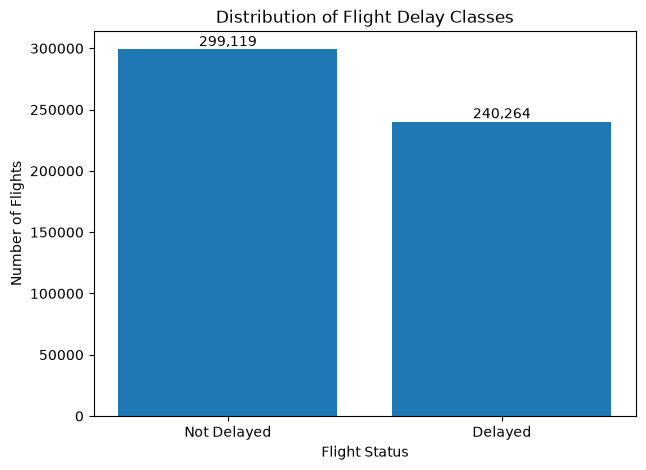

In [40]:
labels = ["Not Delayed", "Delayed"]

plt.figure(figsize=(7, 5))
plt.bar(labels, target_counts.values)

plt.title("Distribution of Flight Delay Classes")
plt.xlabel("Flight Status")
plt.ylabel("Number of Flights")

for i, value in enumerate(target_counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.show()

### 4.4 Delay Rate by Airline

This section examines whether flight delay rates differ across airlines.

In [41]:
airline_delay = (
    df.groupby("Airline", observed=True)["class"]
      .agg(["count", "mean"])
      .rename(columns={
          "count": "Number_of_Flights",
          "mean": "Delay_Rate"
      })
)

airline_delay["Delay_Rate_Percent"] = (
    airline_delay["Delay_Rate"] * 100
).round(2)

airline_delay = airline_delay.sort_values(
    "Delay_Rate_Percent",
    ascending=False
)

airline_delay

,Number_of_Flights,Delay_Rate,Delay_Rate_Percent
Airline,,,
WN,94097,0.697759,69.78
CO,21118,0.566199,56.62
B6,18112,0.467038,46.70
OO,50254,0.452899,45.29
DL,60940,0.450476,45.05
F9,6456,0.449040,44.90
EV,27983,0.402208,40.22
9E,20686,0.397660,39.77
AA,45656,0.388470,38.85


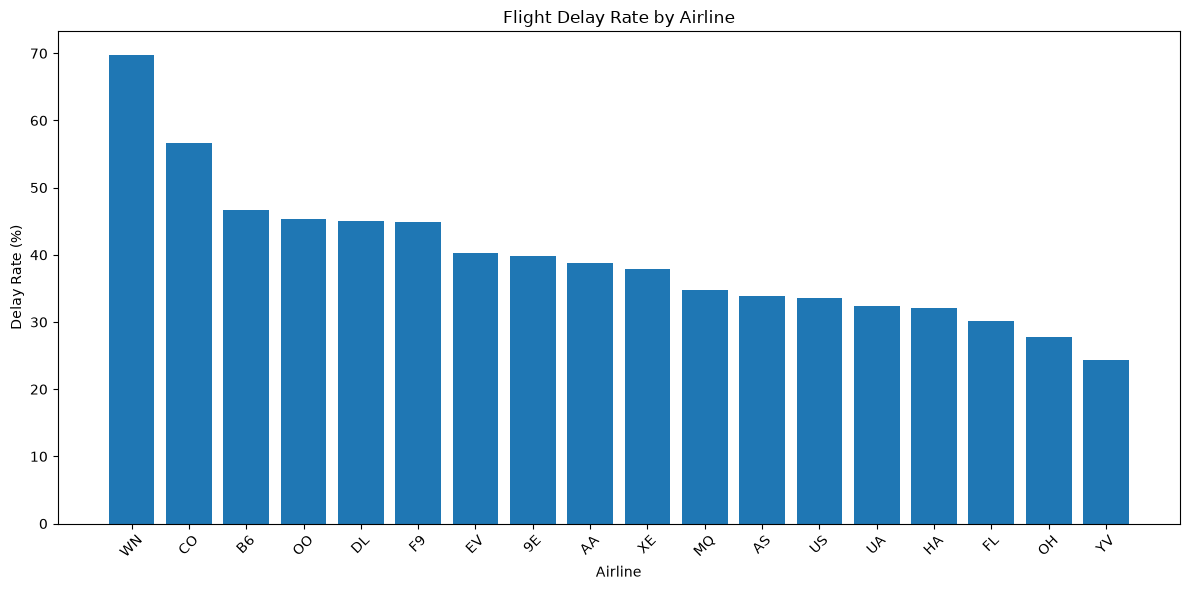

In [42]:
plt.figure(figsize=(12, 6))

plt.bar(
    airline_delay.index,
    airline_delay["Delay_Rate_Percent"]
)

plt.title("Flight Delay Rate by Airline")
plt.xlabel("Airline")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 4.5 Delay Rate by Day of Week

This section examines how flight delay rates vary across different days of the week.

In [43]:
day_delay = (
    df.groupby("DayOfWeek", observed=True)["class"]
      .agg(["count", "mean"])
      .rename(columns={
          "count": "Number_of_Flights",
          "mean": "Delay_Rate"
      })
)

day_delay["Delay_Rate_Percent"] = (
    day_delay["Delay_Rate"] * 100
).round(2)

day_delay = day_delay.sort_index()

day_delay

,Number_of_Flights,Delay_Rate,Delay_Rate_Percent
DayOfWeek,,,
1,72769,0.467644,46.76
2,71340,0.447337,44.73
3,89746,0.470818,47.08
4,91445,0.451025,45.10
5,85248,0.416608,41.66
6,58956,0.400553,40.06
7,69879,0.453541,45.35


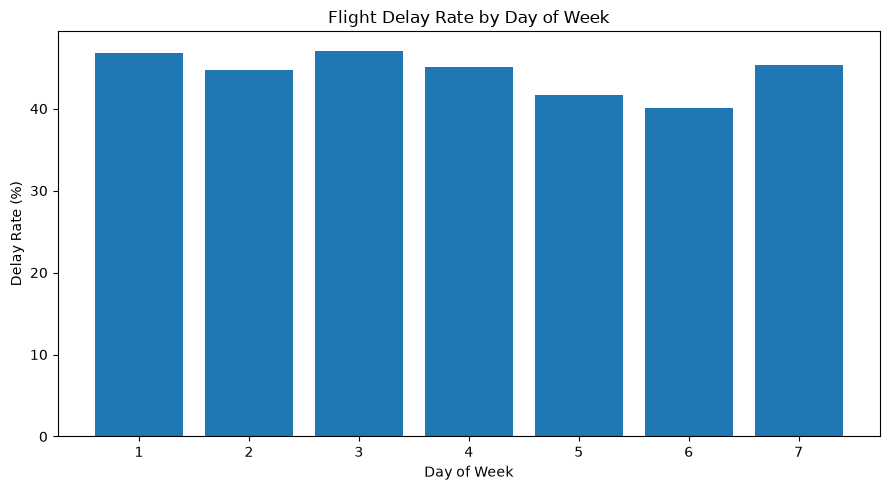

In [44]:
plt.figure(figsize=(9, 5))

plt.bar(
    day_delay.index.astype(str),
    day_delay["Delay_Rate_Percent"]
)

plt.title("Flight Delay Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Delay Rate (%)")

plt.tight_layout()
plt.show()

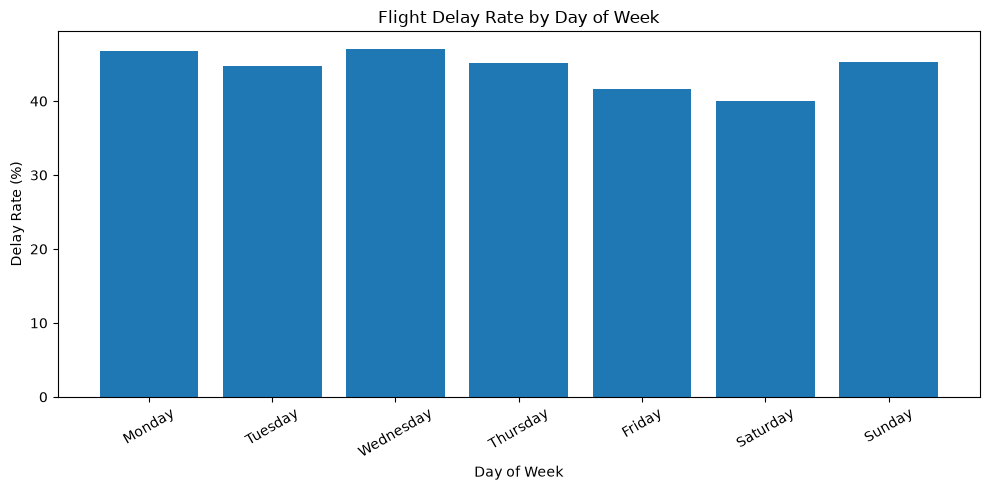

In [45]:
day_names = {
    "1": "Monday",
    "2": "Tuesday",
    "3": "Wednesday",
    "4": "Thursday",
    "5": "Friday",
    "6": "Saturday",
    "7": "Sunday"
}

day_delay_plot = day_delay.copy()
day_delay_plot.index = day_delay_plot.index.map(day_names)

plt.figure(figsize=(10, 5))

plt.bar(
    day_delay_plot.index,
    day_delay_plot["Delay_Rate_Percent"]
)

plt.title("Flight Delay Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### 4.6 Delay Rate by Departure Hour

The `Time` feature represents the scheduled departure time as the number of minutes after midnight.

To make this feature easier to interpret, the scheduled departure hour is derived from `Time`.

In [46]:
df["DepartureHour"] = (df["Time"] // 60).astype(int)

df[["Time", "DepartureHour"]].head(10)

,Time,DepartureHour
0,1235.0,20
1,1296.0,21
2,360.0,6
3,1170.0,19
4,1410.0,23
5,692.0,11
6,580.0,9
7,690.0,11
8,1210.0,20
9,1295.0,21


In [47]:
print("Minimum departure hour:", df["DepartureHour"].min())
print("Maximum departure hour:", df["DepartureHour"].max())

Minimum departure hour: 0
Maximum departure hour: 23


In [48]:
hour_delay = (
    df.groupby("DepartureHour")["class"]
      .agg(["count", "mean"])
      .rename(columns={
          "count": "Number_of_Flights",
          "mean": "Delay_Rate"
      })
)

hour_delay["Delay_Rate_Percent"] = (
    hour_delay["Delay_Rate"] * 100
).round(2)

hour_delay

,Number_of_Flights,Delay_Rate,Delay_Rate_Percent
DepartureHour,,,
0,802,0.471322,47.13
1,346,0.393064,39.31
2,89,0.449438,44.94
4,99,0.404040,40.40
5,4840,0.233678,23.37
6,38859,0.256697,25.67
7,36847,0.302060,30.21
8,37510,0.346494,34.65
9,33622,0.404676,40.47


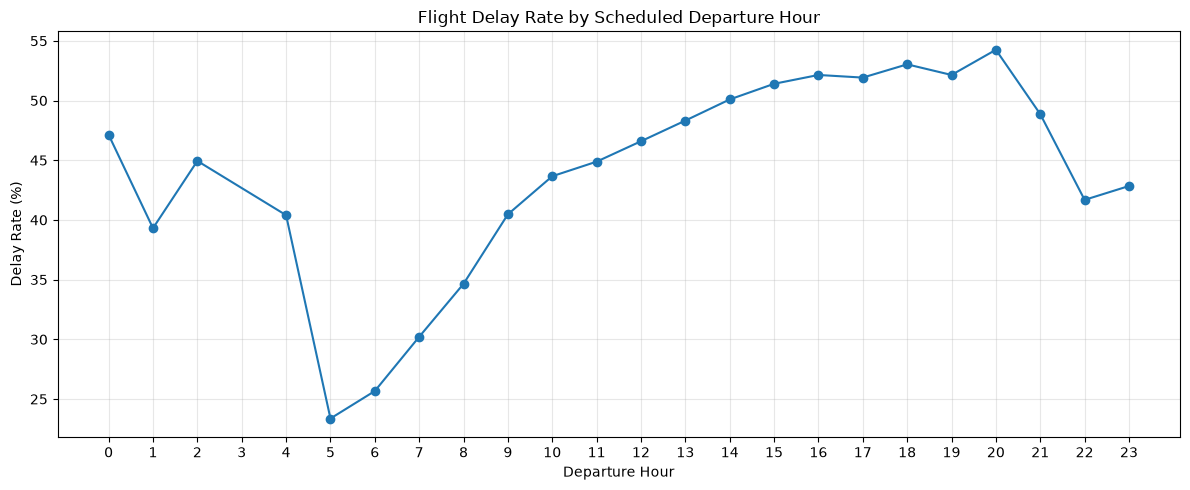

In [49]:
plt.figure(figsize=(12, 5))

plt.plot(
    hour_delay.index,
    hour_delay["Delay_Rate_Percent"],
    marker="o"
)

plt.title("Flight Delay Rate by Scheduled Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Delay Rate (%)")
plt.xticks(range(0, 24))

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.7 Flight Length Analysis

This section examines the distribution of scheduled flight length and explores its relationship with flight delays.

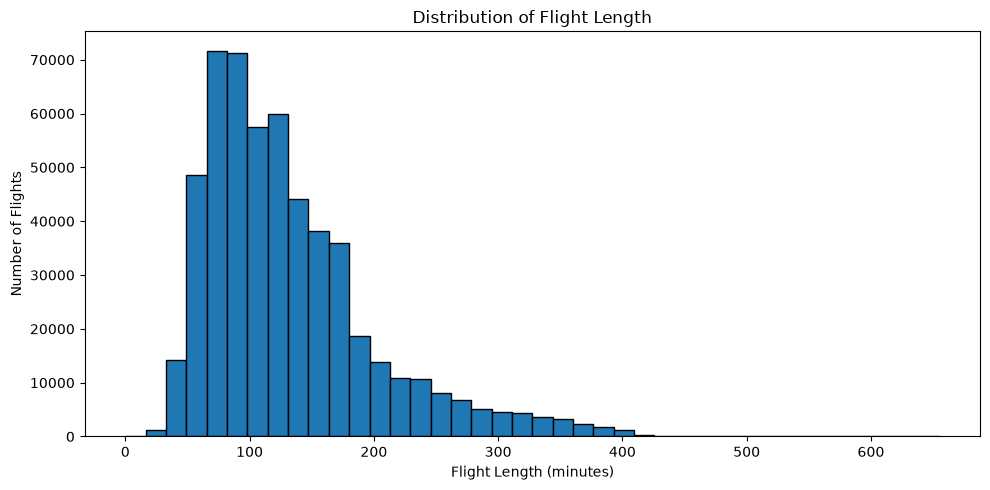

In [50]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["Length"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Flight Length")
plt.xlabel("Flight Length (minutes)")
plt.ylabel("Number of Flights")

plt.tight_layout()
plt.show()

In [51]:
length_by_class = (
    df.groupby("class")["Length"]
      .agg(["count", "mean", "median"])
)

length_by_class.index = ["Not Delayed", "Delayed"]

length_by_class

,count,mean,median
Not Delayed,299119,129.657594,114.0
Delayed,240264,135.369697,118.0


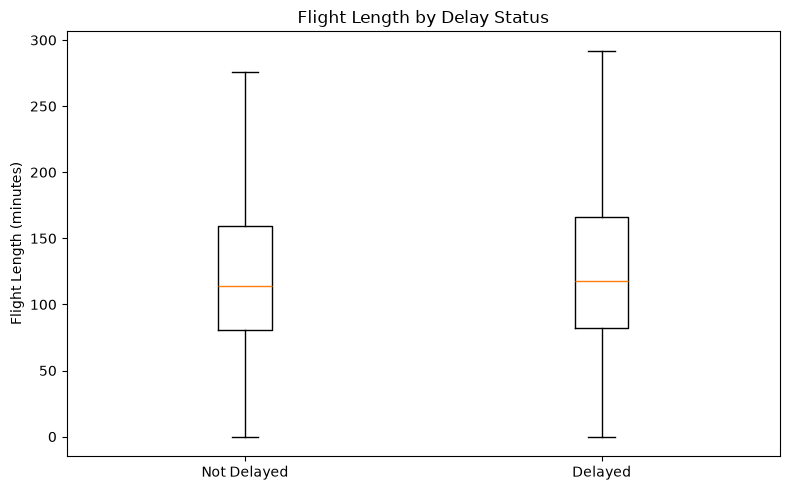

In [52]:
not_delayed_length = df.loc[df["class"] == 0, "Length"]
delayed_length = df.loc[df["class"] == 1, "Length"]

plt.figure(figsize=(8, 5))

plt.boxplot(
    [not_delayed_length, delayed_length],
    tick_labels=["Not Delayed", "Delayed"],
    showfliers=False
)

plt.title("Flight Length by Delay Status")
plt.ylabel("Flight Length (minutes)")

plt.tight_layout()
plt.show()

### 4.8 EDA Summary

The exploratory data analysis produced the following key findings:

- The dataset contains 539,383 flight records and 8 original attributes.
- The target variable is relatively balanced:
  - 55.46% of flights are not delayed.
  - 44.54% of flights are delayed.
- No missing values were identified in the dataset.
- A large number of duplicate-looking observations exist. However, they are not automatically removed because the dataset does not include a specific calendar date, and identical scheduled flight configurations can correspond to different delay outcomes.
- Delay rates vary across airlines.
- Delay rates also vary across different days of the week.
- Scheduled departure time appears to have a relationship with delay probability.
- Flight length shows differences between delayed and non-delayed flights.
- The categorical features `Airline`, `AirportFrom`, `AirportTo`, and `DayOfWeek` will require appropriate encoding before model training.
- The `Flight` feature requires additional consideration because it represents a flight identifier rather than a continuous numerical measurement.

These findings will guide the Data Processing and Modeling stages.

In [53]:
## 5. Data Processing

### 5.1 Feature Selection

The target variable is `class`, where:

- `0` represents a non-delayed flight.
- `1` represents a delayed flight.

The following features will be used for model training:

- `Time`
- `Length`
- `Airline`
- `AirportFrom`
- `AirportTo`
- `DayOfWeek`

The `Flight` feature is excluded from the initial modeling pipeline because it behaves primarily as a high-cardinality flight identifier, with thousands of distinct values. Including it would substantially increase encoding complexity and model size.

`DepartureHour`, which was created during EDA, is also excluded because it is directly derived from the original `Time` feature.

In [54]:
FEATURES = [
    "Time",
    "Length",
    "Airline",
    "AirportFrom",
    "AirportTo",
    "DayOfWeek"
]

TARGET = "class"

X = df[FEATURES].copy()
y = df[TARGET].astype(int).copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.value_counts().sort_index())

Feature matrix shape: (539383, 6)
Target shape: (539383,)


,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek
0,1235.0,80.0,MQ,DFW,CRP,5
1,1296.0,141.0,DL,ATL,HOU,1
2,360.0,146.0,OO,COS,ORD,4
3,1170.0,143.0,B6,BOS,CLT,3
4,1410.0,344.0,US,OGG,PHX,6


class
0    299119
1    240264
Name: count, dtype: int64

### 5.2 Data Type Preparation and Validation

Before splitting the dataset, numerical and categorical features are explicitly assigned appropriate data types.

This helps ensure that the preprocessing pipeline handles each feature consistently during training and deployment.

In [55]:
NUMERIC_FEATURES = [
    "Time",
    "Length"
]

CATEGORICAL_FEATURES = [
    "Airline",
    "AirportFrom",
    "AirportTo",
    "DayOfWeek"
]

# Explicit data types
X[NUMERIC_FEATURES] = X[NUMERIC_FEATURES].astype(float)

for col in CATEGORICAL_FEATURES:
    X[col] = X[col].astype(str)

y = y.astype(int)

print("===== FEATURE DATA TYPES =====")
print(X.dtypes)

print("\n===== TARGET DATA TYPE =====")
print(y.dtype)

===== FEATURE DATA TYPES =====
Time           float64
Length         float64
Airline            str
AirportFrom        str
AirportTo          str
DayOfWeek          str
dtype: object

===== TARGET DATA TYPE =====
int64


In [56]:
print("===== MISSING VALUES =====")
print(X.isnull().sum())

print("\n===== TARGET VALUES =====")
print(sorted(y.unique()))

print("\n===== NUMERIC FEATURE RANGE =====")
print(X[NUMERIC_FEATURES].agg(["min", "max"]))

print("\n===== CATEGORICAL CARDINALITY =====")
for col in CATEGORICAL_FEATURES:
    print(f"{col}: {X[col].nunique()} unique values")

===== MISSING VALUES =====
Time           0
Length         0
Airline        0
AirportFrom    0
AirportTo      0
DayOfWeek      0
dtype: int64

===== TARGET VALUES =====
[np.int64(0), np.int64(1)]

===== NUMERIC FEATURE RANGE =====
       Time  Length
min    10.0     0.0
max  1439.0   655.0

===== CATEGORICAL CARDINALITY =====
Airline: 18 unique values
AirportFrom: 293 unique values
AirportTo: 293 unique values
DayOfWeek: 7 unique values


### 5.3 Train, Validation and Test Split

A conventional random row-level split may introduce data leakage because many records share identical model input features.

To reduce this risk, identical feature combinations are grouped together before splitting. All records with the same model input configuration are assigned to only one of the following sets:

- Training set: approximately 80%
- Validation set: approximately 10%
- Test set: approximately 10%

This produces a more reliable evaluation because identical model inputs do not appear across different data splits.

In [57]:
from sklearn.model_selection import GroupShuffleSplit

In [61]:
# Create a group ID for each unique model input combination
group_index = pd.MultiIndex.from_frame(X[FEATURES])

groups, unique_groups = pd.factorize(group_index)

print("Total rows:", len(X))
print("Unique input combinations:", len(unique_groups))

Total rows: 539383
Unique input combinations: 219226


In [62]:
group_split_1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, temp_idx = next(
    group_split_1.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
y_train = y.iloc[train_idx].copy()

X_temp = X.iloc[temp_idx].copy()
y_temp = y.iloc[temp_idx].copy()

groups_temp = groups[temp_idx]

In [63]:
group_split_2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_relative_idx, test_relative_idx = next(
    group_split_2.split(
        X_temp,
        y_temp,
        groups=groups_temp
    )
)

X_val = X_temp.iloc[val_relative_idx].copy()
y_val = y_temp.iloc[val_relative_idx].copy()

X_test = X_temp.iloc[test_relative_idx].copy()
y_test = y_temp.iloc[test_relative_idx].copy()

In [64]:
print("===== SPLIT SIZES =====")

print(
    f"Train:      {len(X_train):,} "
    f"({len(X_train) / len(X) * 100:.2f}%)"
)

print(
    f"Validation: {len(X_val):,} "
    f"({len(X_val) / len(X) * 100:.2f}%)"
)

print(
    f"Test:       {len(X_test):,} "
    f"({len(X_test) / len(X) * 100:.2f}%)"
)

===== SPLIT SIZES =====
Train:      431,663 (80.03%)
Validation: 53,946 (10.00%)
Test:       53,774 (9.97%)


In [66]:
def show_target_distribution(name, target):
    distribution = (
        target.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

    print(f"\n{name}")
    print(distribution)


show_target_distribution("Train", y_train)
show_target_distribution("Validation", y_val)
show_target_distribution("Test", y_test)


Train
class
0    55.49
1    44.51
Name: proportion, dtype: float64

Validation
class
0    55.04
1    44.96
Name: proportion, dtype: float64

Test
class
0    55.59
1    44.41
Name: proportion, dtype: float64


In [67]:
train_groups = set(groups[train_idx])
val_groups = set(groups[temp_idx][val_relative_idx])
test_groups = set(groups[temp_idx][test_relative_idx])

print(
    "Train ∩ Validation:",
    len(train_groups.intersection(val_groups))
)

print(
    "Train ∩ Test:",
    len(train_groups.intersection(test_groups))
)

print(
    "Validation ∩ Test:",
    len(val_groups.intersection(test_groups))
)

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


### 5.4 Preprocessing Pipeline

A reusable preprocessing pipeline is created to ensure that the same transformations are applied during model training and production inference.

Numerical features:
- `Time`
- `Length`

are standardized using `StandardScaler`.

Categorical features:
- `Airline`
- `AirportFrom`
- `AirportTo`
- `DayOfWeek`

are transformed using `OneHotEncoder`.

`handle_unknown="ignore"` is used so that the deployed API can safely handle categorical values that were not observed during model training.

In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import clone

In [69]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            NUMERIC_FEATURES
        ),
        (
            "categorical",
            categorical_transformer,
            CATEGORICAL_FEATURES
        )
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

In [70]:
preprocessor_preview = clone(preprocessor)

X_train_transformed = preprocessor_preview.fit_transform(X_train)

print("Original training shape:")
print(X_train.shape)

print("\nTransformed training shape:")
print(X_train_transformed.shape)

print("\nTransformed data type:")
print(type(X_train_transformed))

Original training shape:
(431663, 6)

Transformed training shape:
(431663, 613)

Transformed data type:
<class 'scipy.sparse._csr.csr_matrix'>


In [71]:
feature_names = (
    preprocessor_preview
    .get_feature_names_out()
)

print("Number of features after preprocessing:", len(feature_names))

print("\nFirst 20 transformed features:")
print(feature_names[:20])

Number of features after preprocessing: 613

First 20 transformed features:
['numeric__Time' 'numeric__Length' 'categorical__Airline_9E'
 'categorical__Airline_AA' 'categorical__Airline_AS'
 'categorical__Airline_B6' 'categorical__Airline_CO'
 'categorical__Airline_DL' 'categorical__Airline_EV'
 'categorical__Airline_F9' 'categorical__Airline_FL'
 'categorical__Airline_HA' 'categorical__Airline_MQ'
 'categorical__Airline_OH' 'categorical__Airline_OO'
 'categorical__Airline_UA' 'categorical__Airline_US'
 'categorical__Airline_WN' 'categorical__Airline_XE'
 'categorical__Airline_YV']


## 6. Modeling and Evaluation

### 6.1 Baseline Model - Logistic Regression

Logistic Regression is used as the baseline classification model.

The preprocessing transformer and classifier are combined into a single Scikit-learn Pipeline so that preprocessing is applied consistently during both training and inference.

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

In [73]:
logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [74]:
y_val_pred_logistic = logistic_pipeline.predict(X_val)

y_val_prob_logistic = logistic_pipeline.predict_proba(X_val)[:, 1]

In [75]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [76]:
logistic_metrics = {
    "Accuracy": accuracy_score(
        y_val,
        y_val_pred_logistic
    ),
    "Precision": precision_score(
        y_val,
        y_val_pred_logistic
    ),
    "Recall": recall_score(
        y_val,
        y_val_pred_logistic
    ),
    "F1": f1_score(
        y_val,
        y_val_pred_logistic
    ),
    "ROC_AUC": roc_auc_score(
        y_val,
        y_val_prob_logistic
    )
}

pd.DataFrame(
    logistic_metrics,
    index=["Logistic Regression"]
).round(4)

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.644,0.6339,0.4929,0.5545,0.6933


In [77]:
print(
    classification_report(
        y_val,
        y_val_pred_logistic,
        target_names=[
            "Not Delayed",
            "Delayed"
        ]
    )
)

              precision    recall  f1-score   support

 Not Delayed       0.65      0.77      0.70     29694
     Delayed       0.63      0.49      0.55     24252

    accuracy                           0.64     53946
   macro avg       0.64      0.63      0.63     53946
weighted avg       0.64      0.64      0.64     53946



In [78]:
cm_logistic = confusion_matrix(
    y_val,
    y_val_pred_logistic
)

cm_logistic

array([[22790,  6904],
       [12299, 11953]])

### 6.2 Random Forest

Random Forest is evaluated as a nonlinear ensemble model.

Unlike Logistic Regression, Random Forest can capture more complex relationships and interactions between flight characteristics.

To keep training computationally manageable on the large dataset, the number and depth of decision trees are constrained.

In [79]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=20,
                min_samples_leaf=5,
                n_jobs=-1,
                random_state=42
            )
        )
    ]
)

random_forest_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

In [80]:
import time

start_time = time.time()

random_forest_pipeline.fit(
    X_train,
    y_train
)

rf_training_time = time.time() - start_time

print(
    f"Random Forest training completed in "
    f"{rf_training_time:.2f} seconds."
)

Random Forest training completed in 39.21 seconds.


In [81]:
y_val_pred_rf = random_forest_pipeline.predict(
    X_val
)

y_val_prob_rf = random_forest_pipeline.predict_proba(
    X_val
)[:, 1]

In [82]:
rf_metrics = {
    "Accuracy": accuracy_score(
        y_val,
        y_val_pred_rf
    ),
    "Precision": precision_score(
        y_val,
        y_val_pred_rf
    ),
    "Recall": recall_score(
        y_val,
        y_val_pred_rf
    ),
    "F1": f1_score(
        y_val,
        y_val_pred_rf
    ),
    "ROC_AUC": roc_auc_score(
        y_val,
        y_val_prob_rf
    )
}

pd.DataFrame(
    rf_metrics,
    index=["Random Forest"]
).round(4)

,Accuracy,Precision,Recall,F1,ROC_AUC
Random Forest,0.6411,0.7134,0.3371,0.4578,0.7013


In [83]:
print(
    classification_report(
        y_val,
        y_val_pred_rf,
        target_names=[
            "Not Delayed",
            "Delayed"
        ]
    )
)

              precision    recall  f1-score   support

 Not Delayed       0.62      0.89      0.73     29694
     Delayed       0.71      0.34      0.46     24252

    accuracy                           0.64     53946
   macro avg       0.67      0.61      0.59     53946
weighted avg       0.66      0.64      0.61     53946



In [84]:
cm_rf = confusion_matrix(
    y_val,
    y_val_pred_rf
)

cm_rf

array([[26410,  3284],
       [16077,  8175]])

### 6.3 XGBoost

XGBoost is evaluated as a gradient boosting model capable of capturing nonlinear relationships between flight characteristics and delay outcomes.

The model is combined with the same preprocessing pipeline used by the previous models to ensure a consistent comparison.

In [85]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [86]:
from xgboost import XGBClassifier

In [87]:
xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                device="cpu",
                n_jobs=-1,
                random_state=42
            )
        )
    ]
)

xgboost_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

In [88]:
import time

start_time = time.time()

xgboost_pipeline.fit(
    X_train,
    y_train
)

xgb_training_time = time.time() - start_time

print(
    f"XGBoost training completed in "
    f"{xgb_training_time:.2f} seconds."
)

XGBoost training completed in 18.04 seconds.


In [89]:
y_val_pred_xgb = xgboost_pipeline.predict(X_val)

y_val_prob_xgb = xgboost_pipeline.predict_proba(
    X_val
)[:, 1]

In [90]:
xgb_metrics = {
    "Accuracy": accuracy_score(
        y_val,
        y_val_pred_xgb
    ),
    "Precision": precision_score(
        y_val,
        y_val_pred_xgb
    ),
    "Recall": recall_score(
        y_val,
        y_val_pred_xgb
    ),
    "F1": f1_score(
        y_val,
        y_val_pred_xgb
    ),
    "ROC_AUC": roc_auc_score(
        y_val,
        y_val_prob_xgb
    )
}

pd.DataFrame(
    xgb_metrics,
    index=["XGBoost"]
).round(4)

,Accuracy,Precision,Recall,F1,ROC_AUC
XGBoost,0.6616,0.6827,0.462,0.5511,0.7136


In [91]:
print(
    classification_report(
        y_val,
        y_val_pred_xgb,
        target_names=[
            "Not Delayed",
            "Delayed"
        ]
    )
)

              precision    recall  f1-score   support

 Not Delayed       0.65      0.82      0.73     29694
     Delayed       0.68      0.46      0.55     24252

    accuracy                           0.66     53946
   macro avg       0.67      0.64      0.64     53946
weighted avg       0.67      0.66      0.65     53946



In [92]:
cm_xgb = confusion_matrix(
    y_val,
    y_val_pred_xgb
)

cm_xgb

array([[24486,  5208],
       [13048, 11204]])

### 6.4 Model Comparison and Selection

The three candidate models are compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

ROC-AUC is used as an important model-selection metric because it evaluates the model's ability to distinguish between delayed and non-delayed flights across different classification thresholds.

In [93]:
model_comparison = pd.DataFrame(
    {
        "Logistic Regression": logistic_metrics,
        "Random Forest": rf_metrics,
        "XGBoost": xgb_metrics
    }
).T

model_comparison = model_comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
]

model_comparison.round(4)

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.6440,0.6339,0.4929,0.5545,0.6933
Random Forest,0.6411,0.7134,0.3371,0.4578,0.7013
XGBoost,0.6616,0.6827,0.4620,0.5511,0.7136


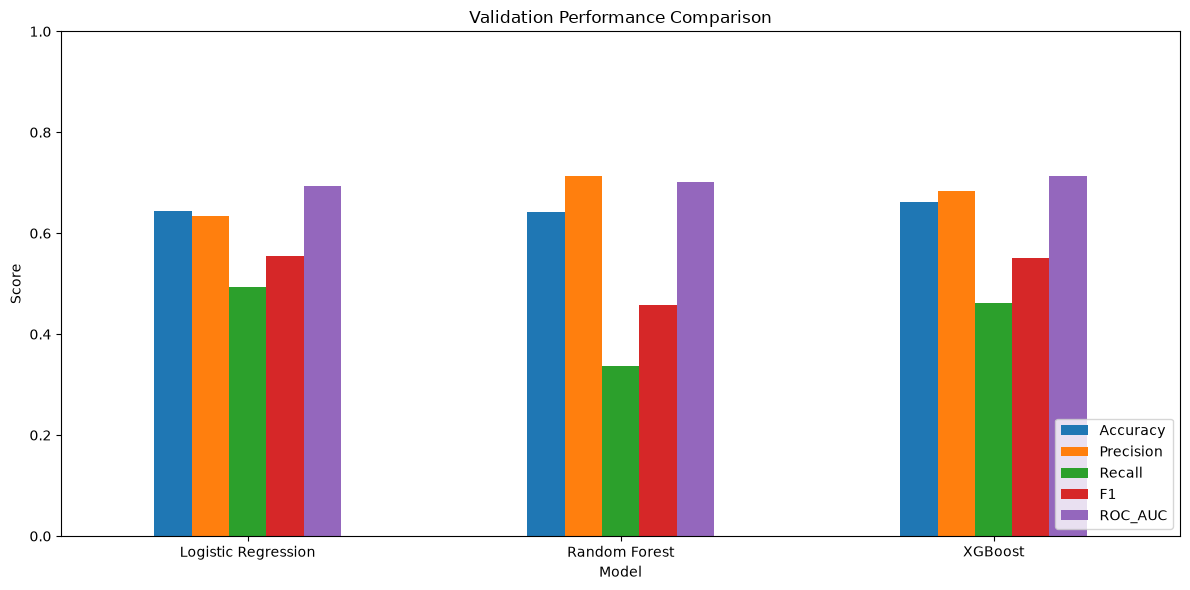

In [94]:
model_comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Validation Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [95]:
best_model_name = model_comparison["ROC_AUC"].idxmax()

print("Best model based on ROC-AUC:", best_model_name)
print(
    "Best ROC-AUC:",
    round(model_comparison.loc[best_model_name, "ROC_AUC"], 4)
)

Best model based on ROC-AUC: XGBoost
Best ROC-AUC: 0.7136


#### Model Selection

XGBoost is selected as the final model.

On the validation set, XGBoost achieved:

- Accuracy: 0.6616
- Precision: 0.6827
- Recall: 0.4620
- F1-score: 0.5511
- ROC-AUC: 0.7136

XGBoost achieved the highest Accuracy and ROC-AUC among the evaluated models.

Logistic Regression achieved a slightly higher Recall and F1-score, while Random Forest achieved the highest Precision. However, XGBoost provides the strongest overall discrimination performance according to ROC-AUC and is therefore selected for final deployment.

### 6.5 Final Evaluation on Test Set

After selecting XGBoost based on validation performance, the final model is evaluated once on the unseen test set.

The test set was not used during model training or model selection.

In [97]:
y_test_pred_xgb = xgboost_pipeline.predict(X_test)

y_test_prob_xgb = xgboost_pipeline.predict_proba(
    X_test
)[:, 1]

In [98]:
xgb_test_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_test_pred_xgb
    ),
    "Precision": precision_score(
        y_test,
        y_test_pred_xgb
    ),
    "Recall": recall_score(
        y_test,
        y_test_pred_xgb
    ),
    "F1": f1_score(
        y_test,
        y_test_pred_xgb
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        y_test_prob_xgb
    )
}

pd.DataFrame(
    xgb_test_metrics,
    index=["XGBoost - Test Set"]
).round(4)

,Accuracy,Precision,Recall,F1,ROC_AUC
XGBoost - Test Set,0.66,0.6745,0.4531,0.542,0.7073


In [99]:
print(
    classification_report(
        y_test,
        y_test_pred_xgb,
        target_names=[
            "Not Delayed",
            "Delayed"
        ]
    )
)

              precision    recall  f1-score   support

 Not Delayed       0.65      0.83      0.73     29894
     Delayed       0.67      0.45      0.54     23880

    accuracy                           0.66     53774
   macro avg       0.66      0.64      0.64     53774
weighted avg       0.66      0.66      0.65     53774



In [100]:
cm_xgb_test = confusion_matrix(
    y_test,
    y_test_pred_xgb
)

cm_xgb_test

array([[24672,  5222],
       [13061, 10819]])

## 7. Prepare for Deployment

### 7.1 Export Trained Pipeline

The complete XGBoost pipeline, including preprocessing and the trained classifier, is exported as a single artifact.

This ensures that the same preprocessing logic used during training will also be applied during API inference.

In [102]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "flight_delay_pipeline.joblib"

joblib.dump(
    xgboost_pipeline,
    MODEL_PATH
)

print("Model saved to:", MODEL_PATH)

Model saved to: ../models/flight_delay_pipeline.joblib


In [104]:
print("Exists:", MODEL_PATH.exists())
print(
    "Size (MB):",
    round(MODEL_PATH.stat().st_size / (1024 ** 2), 2)
)

Exists: True
Size (MB): 1.19


### 7.2 Validate Exported Model

The exported model artifact is loaded again from disk to verify that it can perform inference independently.

Predictions from the reloaded model are compared with predictions from the original in-memory pipeline to ensure consistency.

In [105]:
loaded_pipeline = joblib.load(
    "../models/flight_delay_pipeline.joblib"
)

print("Model loaded successfully.")
print(type(loaded_pipeline))

Model loaded successfully.
<class 'sklearn.pipeline.Pipeline'>


In [106]:
sample_X = X_test.head(10).copy()

sample_X

,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek
4,1410.0,344.0,US,OGG,PHX,6
6,580.0,60.0,WN,MSY,BHM,4
22,720.0,85.0,WN,SAN,OAK,6
24,865.0,64.0,XE,ROC,CLE,7
34,600.0,117.0,US,CLT,DTW,4
35,368.0,118.0,XE,IND,EWR,1
38,421.0,132.0,UA,ORD,LGA,1
70,1267.0,217.0,CO,SEA,ANC,1
89,445.0,151.0,UA,PDX,DEN,1
117,385.0,67.0,EV,HSV,MEM,3


In [107]:
original_predictions = xgboost_pipeline.predict(
    sample_X
)

original_probabilities = xgboost_pipeline.predict_proba(
    sample_X
)[:, 1]

In [108]:
loaded_predictions = loaded_pipeline.predict(
    sample_X
)

loaded_probabilities = loaded_pipeline.predict_proba(
    sample_X
)[:, 1]

In [109]:
comparison = sample_X.copy()

comparison["Original_Prediction"] = original_predictions
comparison["Loaded_Prediction"] = loaded_predictions

comparison["Original_Probability"] = (
    original_probabilities.round(4)
)

comparison["Loaded_Probability"] = (
    loaded_probabilities.round(4)
)

comparison

,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,Original_Prediction,Loaded_Prediction,Original_Probability,Loaded_Probability
4,1410.0,344.0,US,OGG,PHX,6,0,0,0.2227,0.2227
6,580.0,60.0,WN,MSY,BHM,4,0,0,0.4865,0.4865
22,720.0,85.0,WN,SAN,OAK,6,1,1,0.6757,0.6757
24,865.0,64.0,XE,ROC,CLE,7,0,0,0.3775,0.3775
34,600.0,117.0,US,CLT,DTW,4,0,0,0.3791,0.3791
35,368.0,118.0,XE,IND,EWR,1,0,0,0.2269,0.2269
38,421.0,132.0,UA,ORD,LGA,1,0,0,0.1680,0.1680
70,1267.0,217.0,CO,SEA,ANC,1,1,1,0.5905,0.5905
89,445.0,151.0,UA,PDX,DEN,1,0,0,0.2041,0.2041
117,385.0,67.0,EV,HSV,MEM,3,0,0,0.1903,0.1903


In [110]:
import numpy as np

prediction_match = np.array_equal(
    original_predictions,
    loaded_predictions
)

probability_match = np.allclose(
    original_probabilities,
    loaded_probabilities
)

print(
    "Predictions identical:",
    prediction_match
)

print(
    "Probabilities identical:",
    probability_match
)

Predictions identical: True
Probabilities identical: True


### 7.3 Day 2 Summary

The Data Processing, Modeling, Evaluation, and Prepare for Deployment stages have been completed.

#### Data Processing
- Six input features were selected:
  - Time
  - Length
  - Airline
  - AirportFrom
  - AirportTo
  - DayOfWeek
- `Flight` was excluded because it behaves as a high-cardinality identifier.
- Numerical and categorical features were explicitly separated.
- A group-based Train/Validation/Test split was used to prevent identical input combinations from appearing across different datasets.
- The final split was approximately:
  - Train: 80%
  - Validation: 10%
  - Test: 10%
- A preprocessing pipeline was created using:
  - StandardScaler for numerical features.
  - OneHotEncoder for categorical features.

#### Model Comparison

Three classification models were evaluated:

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.6440 | 0.6339 | 0.4929 | 0.5545 | 0.6933 |
| Random Forest | 0.6411 | 0.7134 | 0.3371 | 0.4578 | 0.7013 |
| XGBoost | 0.6616 | 0.6827 | 0.4620 | 0.5511 | 0.7136 |

XGBoost was selected as the final model because it achieved the highest validation Accuracy and ROC-AUC.

#### Final Test Performance

The selected XGBoost model achieved:

- Accuracy: 0.6600
- Precision: 0.6745
- Recall: 0.4531
- F1-score: 0.5420
- ROC-AUC: 0.7073

The validation and test ROC-AUC scores were close, indicating relatively stable generalization performance.

#### Deployment Artifact

The complete preprocessing and XGBoost pipeline was exported to:

`models/flight_delay_pipeline.joblib`

The exported artifact was loaded again from disk and successfully reproduced the same predictions and probabilities as the original in-memory model.

The model artifact is now ready to be integrated into the FastAPI service.

In [103]:
## 6. Modeling and Evaluation

In [ ]:
## 6. Modeling and Evaluation